In [111]:
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.interpolate as spi
%matplotlib Qt

In [87]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_one_lead = mat_struct["ecg_lead"]
ecg_one_lead = ecg_one_lead.flatten()

qrs_detections = mat_struct["qrs_detections"]


In [88]:
fs = 1000  # Hz
nyq_frec = fs / 2

N = 10000

In [89]:
ecg_one_lead_10 = ecg_one_lead[:N]
df_p = fs / N

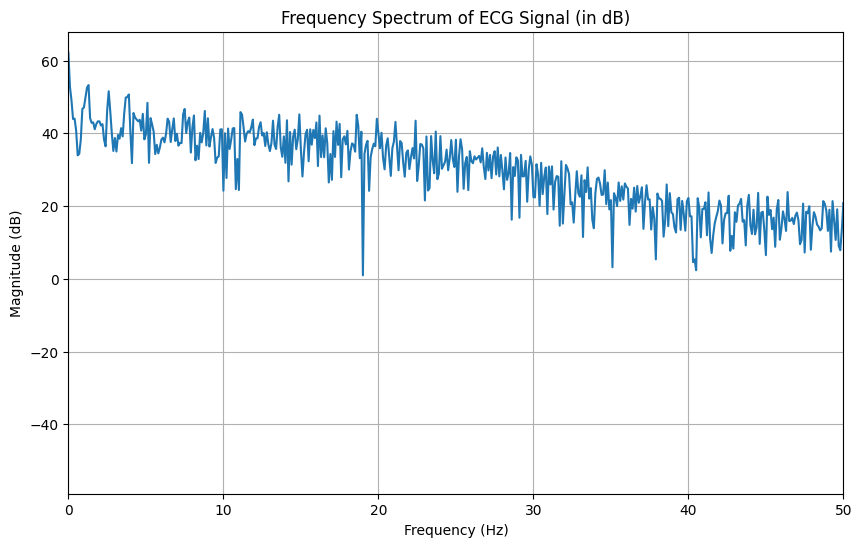

In [90]:
frequencies = np.fft.fftfreq(N, 1/fs)  # frequency axis
fft_values = np.fft.fft(ecg_one_lead_10)      # Fourier Transform

# Calculate the magnitude spectrum in dB
magnitude_spectrum_db = 20 * np.log10(np.abs(fft_values) / N)

# Plotting the frequency spectrum in dB (only positive frequencies)
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:N // 2], magnitude_spectrum_db[:N // 2])  # positive frequencies
plt.title('Frequency Spectrum of ECG Signal (in dB)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, 50)
plt.grid()
plt.show()

In [91]:
ms = 75
s = ms / 1000
offset = int(s * fs)
offset

75

In [92]:
from itertools import takewhile

slice_of_detections = list(takewhile(lambda x: x <= N, qrs_detections))
print(max(slice_of_detections))

[8875]


In [93]:
puntos_de_interes = [int(m[0]) - offset for m in slice_of_detections]

Utilizamos los segmentos isoelectricos del ECG como puntos de interes para trazar la linea de base a travéz de un método de interpolación

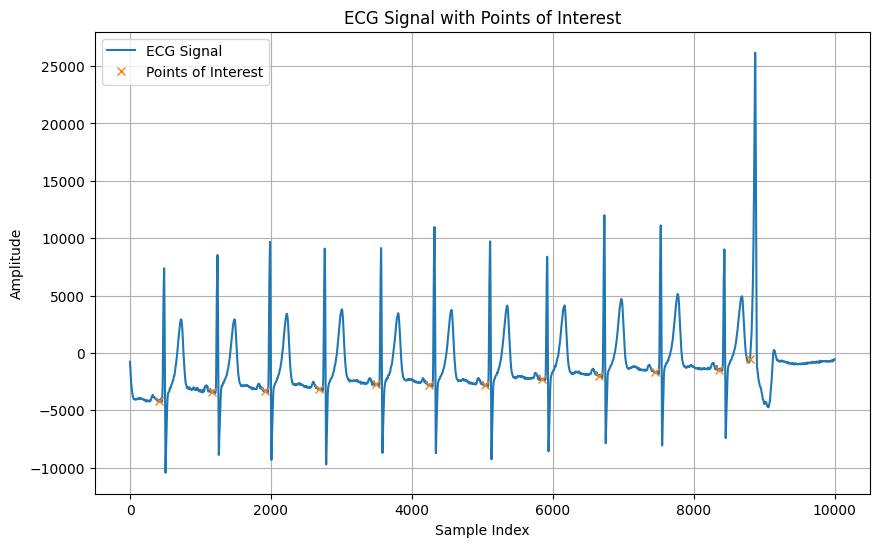

In [94]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_one_lead_10, label='ECG Signal')

plt.plot(puntos_de_interes, ecg_one_lead_10[puntos_de_interes], 'x', label='Points of Interest')

# Adding labels and legend
plt.title('ECG Signal with Points of Interest')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

In [95]:
amplitudes_of_interest = ecg_one_lead_10[puntos_de_interes]

In [96]:
cs = spi.CubicSpline(puntos_de_interes, amplitudes_of_interest)

In [97]:
x = np.linspace(0, N -1, N)
noise_interpolated = cs(x)

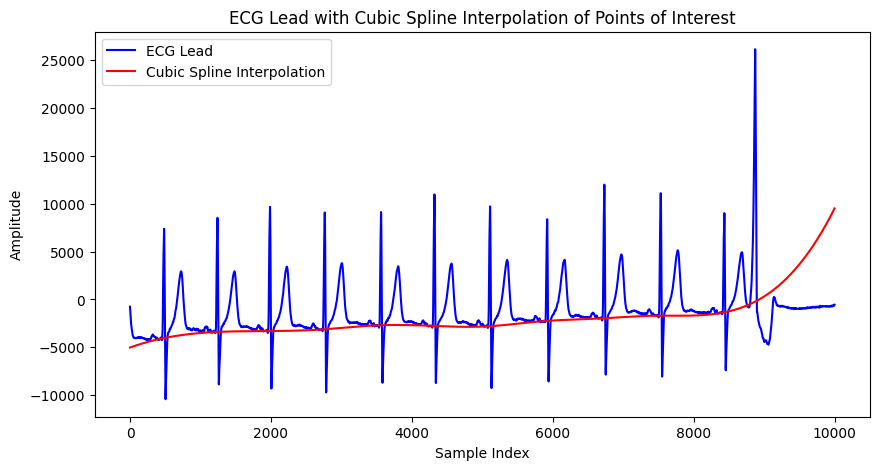

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead_10, label="ECG Lead", color="blue")
plt.plot(x, noise_interpolated, label="Cubic Spline Interpolation", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.show()

In [99]:
filtered_signal = ecg_one_lead_10 - noise_interpolated

Para filtrar la señal simplemente sustraemos la línea de interpolación de la propia señal

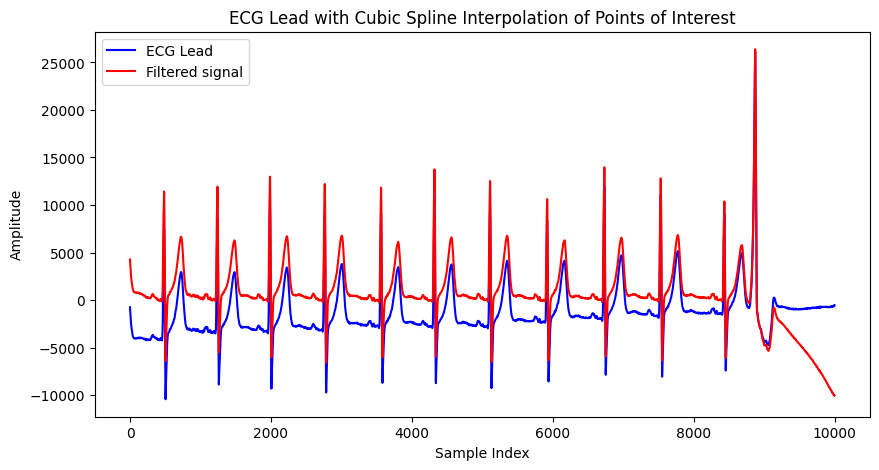

In [100]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead_10, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Filtered signal", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.show()

Aplicamos el mismo metodo ahora para toda la señal

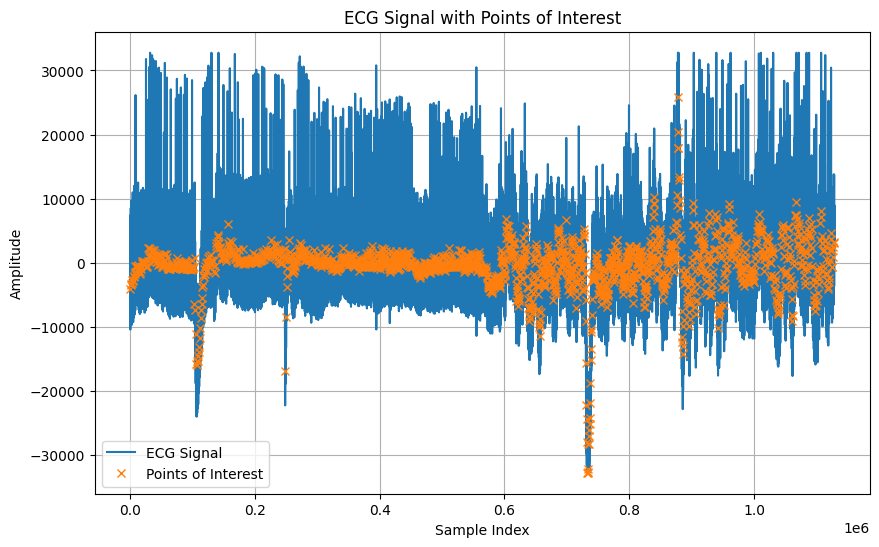

In [102]:
puntos_de_interes = [int(m[0]) - offset for m in qrs_detections]
plt.figure(figsize=(10, 6))
plt.plot(ecg_one_lead, label='ECG Signal')

plt.plot(puntos_de_interes, ecg_one_lead[puntos_de_interes], 'x', label='Points of Interest')

# Adding labels and legend
plt.title('ECG Signal with Points of Interest')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

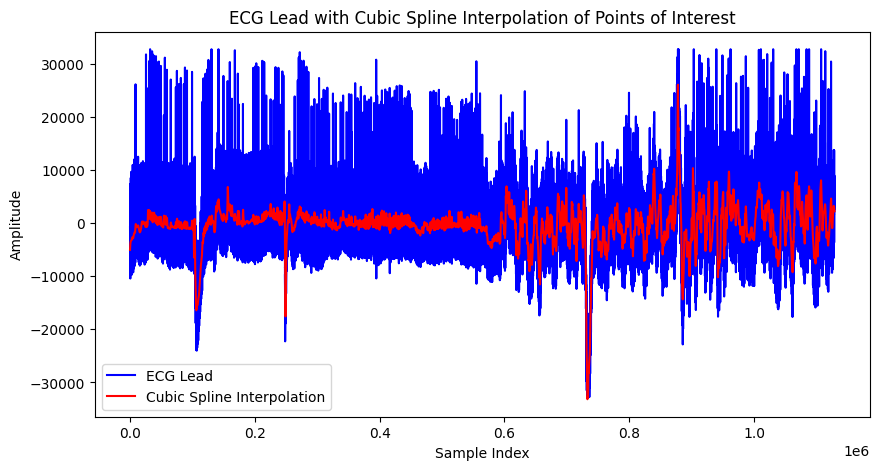

In [103]:
amplitudes_of_interest = ecg_one_lead[puntos_de_interes]
cs = spi.CubicSpline(puntos_de_interes, amplitudes_of_interest)

N = len(ecg_one_lead)

x = np.linspace(0, N -1, N)
noise_interpolated = cs(x)

plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(x, noise_interpolated, label="Cubic Spline Interpolation", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.show()

In [104]:
filtered_signal = ecg_one_lead - noise_interpolated

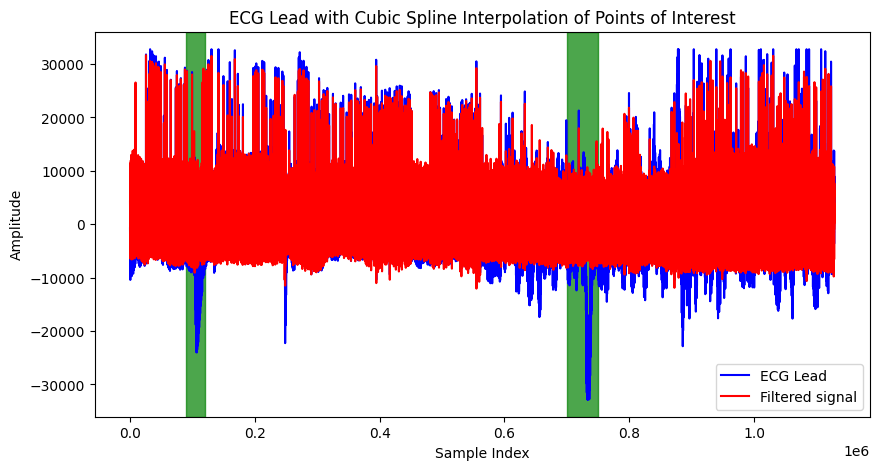

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Filtered signal", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.axvspan(90000, 120000, color='green', alpha=0.7)  # Shaded region
plt.axvspan(700000, 750000, color='green', alpha=0.7)  # Shaded region

plt.show()

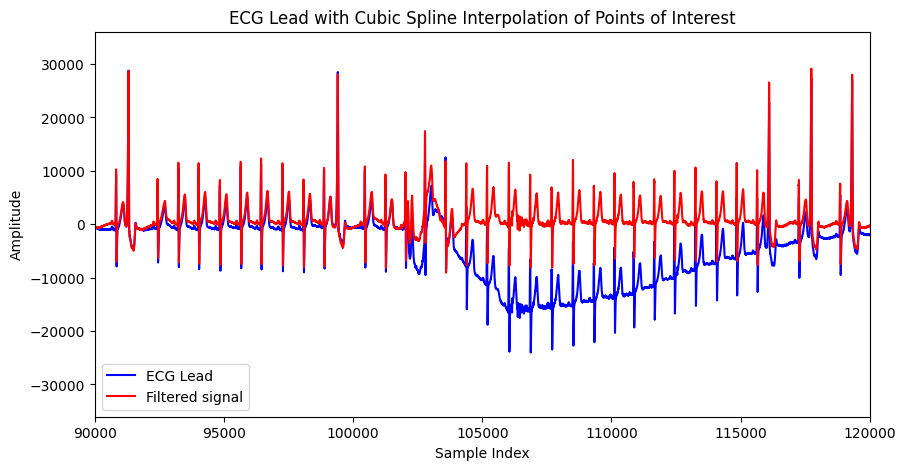

In [106]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Filtered signal", color="red")
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.xlim(90000,120000 )
plt.show()


A simple vista ya se puede observar como el filtro actuo sobre los picos de la señal

In [ ]:
# Calculate the magnitude spectrum in dB
magnitude_spectum_db = 20 * np.log10(np.abs(fft_values) / N)

frequencies = np.fft.fftfreq(N, 1/fs)  # frequency axis
fft_values = np.fft.fft(filtered_signal)      # Fourier Transform

# Calculate the magnitude spectrum in dB
filtered_magnitude_spectrum_db = 20 * np.log10(np.abs(fft_values) / N)

# Plotting the frequency spectrum in dB (only positive frequencies)
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:N // 2], filtered_magnitude_spectrum_db[:N // 2], label='Filtered Signal', color='blue')
plt.plot(
    frequencies[:N // 2],
    magnitude_spectrum_db[:N // 2],
    label='Original Signal',
    color='red',
    linestyle='--',

)
plt.title('Frequency Spectrum of ECG Signal (in dB)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, 5)
plt.grid()
plt.legend()
plt.show()

Por su complejidad computacional, el filtro de mediana sera evaluado solo en los primeros 10 segundos de la señal.

Utilizamos dos ventanas para filtrar oscilasiones que tengan una ondulación hasta 100hz y hasta 300hz con las ventanas de 200 y 600 muestras respectivamente

In [108]:
filtered_median_signal_200 = sig.medfilt(ecg_one_lead_10, 201)
filtered_median_signal_600 = sig.medfilt(filtered_median_signal_200, 601)
filtered_signal = ecg_one_lead_10 - filtered_median_signal_600

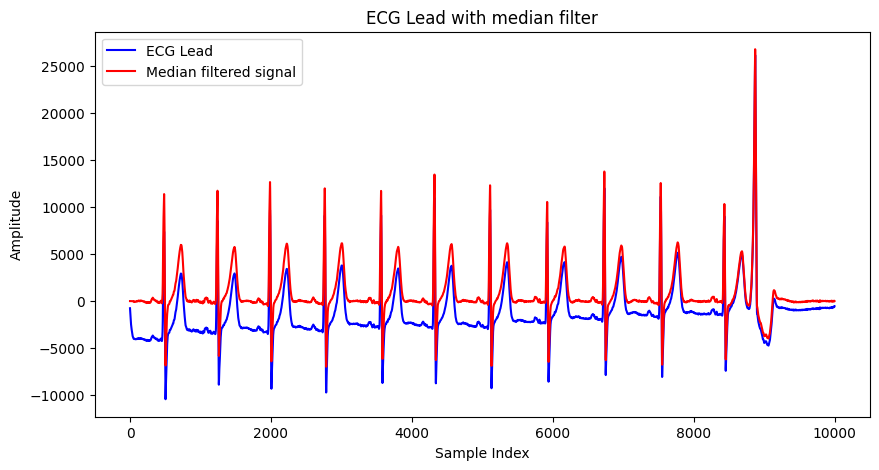

In [109]:

plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead_10, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Median filtered signal", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with median filter")
plt.show()

In [113]:
N = 10000
frequencies = np.fft.fftfreq(N, 1/fs)  # frequency axis
fft_values = np.fft.fft(ecg_one_lead_10)      # Fourier Transform

# Calculate the magnitude spectrum in dB
magnitude_spectrum_db = 20 * np.log10(np.abs(fft_values) / N)

frequencies = np.fft.fftfreq(N, 1/fs)  # frequency axis
fft_values = np.fft.fft(filtered_signal)      # Fourier Transform

# Calculate the magnitude spectrum in dB
filtered_magnitude_spectrum_db = 20 * np.log10(np.abs(fft_values) / N)

# Plotting the frequency spectrum in dB (only positive frequencies)
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:N // 2], filtered_magnitude_spectrum_db[:N // 2], label='Filtered Signal', color='blue')
plt.plot(frequencies[:N // 2], magnitude_spectrum_db[:N // 2], label='Original Signal', color='red', linestyle='--')
plt.title('Frequency Spectrum of ECG Signal (in dB)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid()
plt.legend()
plt.show()